# Unidad 2 · Análisis de sentimiento y tendencias en redes sociales — Extracción y tratamiento de datos

Asignatura: Búsqueda y Análisis de la Información.    
Alumno: Rodrigo de Siqueira-Lima Pérez-Moreno

## Descripción

En esta práctica implementaré la primera fase del proyecto de análisis de sentimiento en redes sociales. Las tareas a realizar en la práctica incluyen:

1. Cargar un dataset de tweets sobre Bitcoin
2. Limpiar y normalizar el texto
3. Extraer hashtags y hacer un análisis básico
4. Generar algunas visualizaciones (wordcloud, gráficas de frecuencia...)

### Dataset

He usado el dataset **Bitcoin Tweets** de Kaggle:
> https://www.kaggle.com/datasets/kaushiksuresh147/bitcointweets

En concreto el archivo `Bitcoin_tweets_dataset_2.csv`, que es el más ligero de los dos (y el que recomienda el enunciado). Tiene tweets relacionados con Bitcoin con información como el texto, la fecha, el usuario y los hashtags.

Toda la lógica de procesamiento va dentro de la clase `DataExtractor`.

## Librerías

In [1]:
import polars as pl
import re
from typing import Dict
import matplotlib.pyplot as plt
from wordcloud import WordCloud

## Clase `DataExtractor`

In [2]:
class DataExtractor:
    def __init__(self, source_file: str, chunksize: int = 100000):
        """
        Inicializa el extractor con el archivo de origen.
        Parámetro:
        source_file: Ruta al archivo de datos (CSV o JSON).
        """
        self.source_file = source_file
        self.data = None
        self.chunksize = chunksize

    def load_data(self) -> pl.DataFrame:
        """
        Carga los datos del archivo de origen.
        Implementación esperada:
        - Leer el archivo en el formato correspondiente (CSV o JSON).
        - Almacenar los datos en self.data.
        """
        if self.source_file.endswith('.csv'):
            self.data = (
                pl.scan_csv(
                    self.source_file,
                    encoding='utf8',
                    ignore_errors=True,
                    infer_schema_length=10000,
                )
                .collect()
            )
        elif self.source_file.endswith('.json'):
            self.data = pl.read_ndjson(self.source_file)
        else:
            raise ValueError("Formato no soportado. Usa CSV o JSON.")
        return self.data

    def clean_text(self, text: str) -> str:
        """
          Limpia y normaliza el texto.
        Pasos sugeridos:
        - Convertir a minúsculas.
        - Eliminar o extraer URLs.
        - Eliminar caracteres especiales (OJO! necesitamos hashtags) y espacios redundantes.
        Devuelve:
        El texto limpio.
        """
        if not isinstance(text, str):
            return ""
        text = text.lower()
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"@\w+", " ", text)
        text = re.sub(r"[^0-9a-z#\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    def extract_hashtags(self, text: str) -> list:
        """
        Extrae y devuelve una lista de hashtags presentes en el texto.
        Implementación sugerida:
        - Utilizar expresiones regulares para encontrar palabras que comiencen con '#' .
        """
        if not isinstance(text, str):
            return []
        return re.findall(r"#\w+", text)

    def analytics_hashtags_extended(self) -> Dict[str, pl.DataFrame]:
        """
        Realiza un análisis avanzado de hashtags sobre el conjunto de datos cargado (self.data).
        El método realiza los siguientes pasos:
        1. Aplica la función clean_text a la columna 'text' para normalizar los datos.
        2. Extrae los hashtags de cada texto usando extract_hashtags y los almacena en una nueva columna.
        3. Convierte la columna 'date' a tipo datetime y extrae solo la fecha (sin la hora).
        4. Explota la columna de hashtags para obtener una fila por cada hashtag, lo que facilita los cálculos de
        frecuencia.
        4
        Centro adscrito a
        5. Calcula tres análisis:
        - Frecuencia total de cada hashtag (overall).
        - Frecuencia de hashtags por usuario (by_user).
        - Evolución de la frecuencia de hashtags por día (by_date).
        Retorna:
        Un diccionario con tres DataFrames, con claves:
        'overall': DataFrame con columnas ['hashtag', 'frequency'].
        'by_user': DataFrame con columnas ['user_name', 'hashtag', 'frequency'].
        'by_date': DataFrame con columnas ['date', 'hashtag', 'frequency'].
        """
        if self.data is None:
            raise ValueError("Datos no cargados. Llama primero a load_data().")
        if 'text' not in self.data.columns:
            raise KeyError("La columna 'text' no existe en el dataset.")

        df = (
            self.data
            .with_columns(
                pl.col('text')
                .map_elements(self.clean_text, return_dtype=pl.String)
                .alias('clean_text')
            )
            .with_columns(
                pl.col('clean_text')
                .map_elements(self.extract_hashtags, return_dtype=pl.List(pl.String))
                .alias('hashtags_ext')
            )
            .with_columns(
                pl.col('date')
                .cast(pl.String)
                .str.to_datetime(format='%Y-%m-%d %H:%M:%S', strict=False)
                .dt.date()
                .alias('date')
            )
        )

        df_exp = (
            df.explode('hashtags_ext')
            .filter(pl.col('hashtags_ext').is_not_null())
            .filter(pl.col('hashtags_ext').str.strip_chars() != '')
        )

        overall = (
            df_exp
            .group_by('hashtags_ext')
            .agg(pl.len().alias('frequency'))
            .rename({'hashtags_ext': 'hashtag'})
            .sort('frequency', descending=True)
        )

        if 'user_name' in df_exp.columns:
            by_user = (
                df_exp
                .group_by(['user_name', 'hashtags_ext'])
                .agg(pl.len().alias('frequency'))
                .rename({'hashtags_ext': 'hashtag'})
                .sort('frequency', descending=True)
            )
        else:
            by_user = pl.DataFrame(schema={'user_name': pl.String, 'hashtag': pl.String, 'frequency': pl.UInt32})

        by_date = (
            df_exp
            .group_by(['date', 'hashtags_ext'])
            .agg(pl.len().alias('frequency'))
            .rename({'hashtags_ext': 'hashtag'})
            .sort(['date', 'frequency'], descending=[False, True])
        )

        return {'overall': overall, 'by_user': by_user, 'by_date': by_date}

    def generate_hashtag_wordcloud(
        self,
        overall_df: pl.DataFrame = None,
        max_words: int = 100,
        figsize: tuple = (10, 6),
    ) -> None:
        """
        Genera y muestra una wordcloud basada en el análisis global de hashtags.
        Este método utiliza el DataFrame 'overall' que contiene la frecuencia global de cada hashtag.
        Si no se proporciona el DataFrame, se calcula llamando a analytics_hashtags_extended().
        Parámetros:
        overall_df (pd.DataFrame, opcional): DataFrame con columnas ['hashtags', 'frequency']. Si es None, se
        calcula.
        max_words (int, opcional): Número máximo de palabras a incluir en la wordcloud.
        figsize (tuple, opcional): Tamaño de la figura a mostrar.
        Proceso:
        frecuencias.
        1. Si overall_df es None, llamar a analytics_hashtags_extended y extraer la parte 'overall'.
        2. Convertir el DataFrame a un diccionario donde las claves sean los hashtags y los valores sean las
        3. Utilizar la clase WordCloud de la librería wordcloud para generar la nube de palabras.
        4. Visualizar la wordcloud con matplotlib.
        """
        if overall_df is None:
            overall_df = self.analytics_hashtags_extended()['overall']

        if overall_df.is_empty():
            print("No hay hashtags para generar la wordcloud.")
            return

        freq_dict = dict(zip(
            overall_df['hashtag'].to_list(),
            overall_df['frequency'].to_list(),
        ))

        wc = WordCloud(
            width=1200,
            height=600,
            background_color='white',
            max_words=max_words,
            colormap='plasma',
        )
        wc.generate_from_frequencies(freq_dict)

        plt.figure(figsize=figsize)
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title('Wordcloud · Hashtags más frecuentes en tweets de Bitcoin', fontsize=14)
        plt.tight_layout()
        plt.show()


## 1. Carga de datos

In [ ]:
SOURCE_FILE = 'data/Bitcoin_tweets_dataset_2.csv'

extractor = DataExtractor(source_file=SOURCE_FILE)
df = extractor.load_data()

print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
print(f"Columnas: {df.columns}")
df.head(3)


Filas: 169,820  |  Columnas: 13
Columnas: ['user_name', 'user_location', 'user_description', 'user_created', 'user_followers', 'user_friends', 'user_favourites', 'user_verified', 'date', 'text', 'hashtags', 'source', 'is_retweet']


user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,is_retweet
str,str,str,str,i64,i64,i64,bool,str,str,str,str,bool
"""ChefSam""","""Sunshine State""","""Culinarian | Hot Sauce Artisan…","""2011-03-23 03:50:13""",4680,2643,6232,false,"""2023-03-01 23:59:59""","""Which #bitcoin books should I …","""['bitcoin']""","""Twitter for iPhone""",false
"""Roy⚡️""",null,"""Truth-seeking pleb 📚 • Science…","""2022-01-30 17:41:41""",770,1145,9166,false,"""2023-03-01 23:59:47""","""@ThankGodForBTC I appreciate t…","""['Bitcoin']""","""Twitter for iPhone""",false
"""Ethereum Yoda""",null,"""UP or DOWN... . . . . Price ma…","""2022-07-24 04:50:18""",576,1,0,false,"""2023-03-01 23:59:42""","""#Ethereum price update: #ETH…","""['Ethereum', 'ETH', 'Bitcoin',…","""Twitter Web App""",false


Antes de limpiar, echo un vistazo al dataset: cuántas filas, de qué fechas son los tweets, cuántos usuarios distintos hay, etc.

In [7]:
dates = df['date'].cast(pl.String).str.to_datetime(format='%Y-%m-%d %H:%M:%S', strict=False)

print("=== Estadísticas ===")
print(f"Total tweets:        {df.shape[0]:,}")
print(f"Usuarios únicos:     {df['user_name'].n_unique():,}")
print(f"Rango de fechas:     {dates.min().date()} → {dates.max().date()}")
print(f"Tweets con hashtag:  {df['hashtags'].is_not_null().sum():,}")
print(f"Retweets:            {df['is_retweet'].sum():,}")
print()
print("=== Valores nulos ===")
print(df.select(['user_name', 'date', 'text', 'hashtags']).null_count())


=== Estadísticas ===
Total tweets:        169,820
Usuarios únicos:     36,292
Rango de fechas:     2023-02-25 → 2023-03-05
Tweets con hashtag:  169,820
Retweets:            0

=== Valores nulos ===
shape: (1, 4)
┌───────────┬──────┬──────┬──────────┐
│ user_name ┆ date ┆ text ┆ hashtags │
│ ---       ┆ ---  ┆ ---  ┆ ---      │
│ u32       ┆ u32  ┆ u32  ┆ u32      │
╞═══════════╪══════╪══════╪══════════╡
│ 1         ┆ 0    ┆ 0    ┆ 0        │
└───────────┴──────┴──────┴──────────┘


## 2. Almacenamiento

In [9]:
OUTPUT_CSV = 'data/Bitcoin_tweets_clean.csv'
df.write_csv(OUTPUT_CSV)
print(f"Datos guardados en '{OUTPUT_CSV}'")

Datos guardados en 'data/Bitcoin_tweets_clean.csv'


## 3. Limpieza del texto

El método clean_text() aplica varias expresiones regulares para limpiar cada tweet:

1. Todo a minúsculas
2. Eliminar URLs
3. Eliminar menciones (@usuario)
4. Eliminar caracteres especiales y emojis, pero conservando "#" porque lo necesito después para los hashtags
5. Colapsar espacios

Abajo pongo algunos ejemplos para ver la diferencia entre el texto original y el limpio:

In [10]:
# Comparativa antes / después de la limpieza sobre una muestra de tweets
sample = df['text'].drop_nulls().sample(8, seed=42).to_list()

print(f"{'ORIGINAL':<65}  →  LIMPIO")
print("-" * 120)
for tweet in sample:
    cleaned = extractor.clean_text(tweet)
    original_preview = tweet.replace('\n', ' ')[:64]
    print(f"{original_preview:<65}  →  {cleaned[:80]}")

ORIGINAL                                                           →  LIMPIO
------------------------------------------------------------------------------------------------------------------------
@BITCOINF_  Similar to how cash is utilized in day-to-day activi   →  similar to how cash is utilized in day to day activities bitcoinf has a high tot
SEC *GOES NUCLEAR* ON CRYPTO | JPMorgan OPENS CRYPTO LAB  watch    →  sec goes nuclear on crypto jpmorgan opens crypto lab watch #sec #bitcoin #crypto
#LDOUSDT Scalping set-up 🟢☝️  🔥To get this type of signals ⤵️🔗 👉   →  #ldousdt scalping set up to get this type of signals #btc #binance #coinbase #ku
@Aramco0913 @justlenasart @saylor @DooridooriCoin @e0LV0sQeSE9TM   →  it s so beautiful #bitcoin
#Bitcoin Update MTF :   1. Bounced off the Wedge's exact bottom    →  #bitcoin update mtf 1 bounced off the wedge s exact bottom trendline thus creati
@HodlMagoo ‘Tis a fact! #bitcoin                                   →  tis a fact #bitcoin
$WOO #Bitco

## 4. Análisis de hashtags

Llamo a analytics_hashtags_extended() que devuelve tres DataFrames:
- verall: frecuencia total de cada hashtag
- by_user: cuántas veces usa cada usuario cada hashtag
- by_date: evolución día a día

In [11]:
analytics = extractor.analytics_hashtags_extended()
overall  = analytics['overall']
by_user  = analytics['by_user']
by_date  = analytics['by_date']

print(f"Hashtags únicos encontrados: {len(overall):,}")
print("\nTop 20 hashtags más frecuentes:")
display(overall.head(20))


Hashtags únicos encontrados: 25,442

Top 20 hashtags más frecuentes:


hashtag,frequency
str,u32
"""#bitcoin""",156113
"""#btc""",67126
"""#crypto""",63748
"""#cryptocurrency""",34866
"""#eth""",33088
…,…
"""#xrp""",5772
"""#binancecoin""",5423
"""#ai""",4692


### Top 20 hashtags más frecuentes

#bitcoin domina con mucha diferencia, aunque tambieén aparecen hashtags de otras criptos como #ethereum o #xrp.

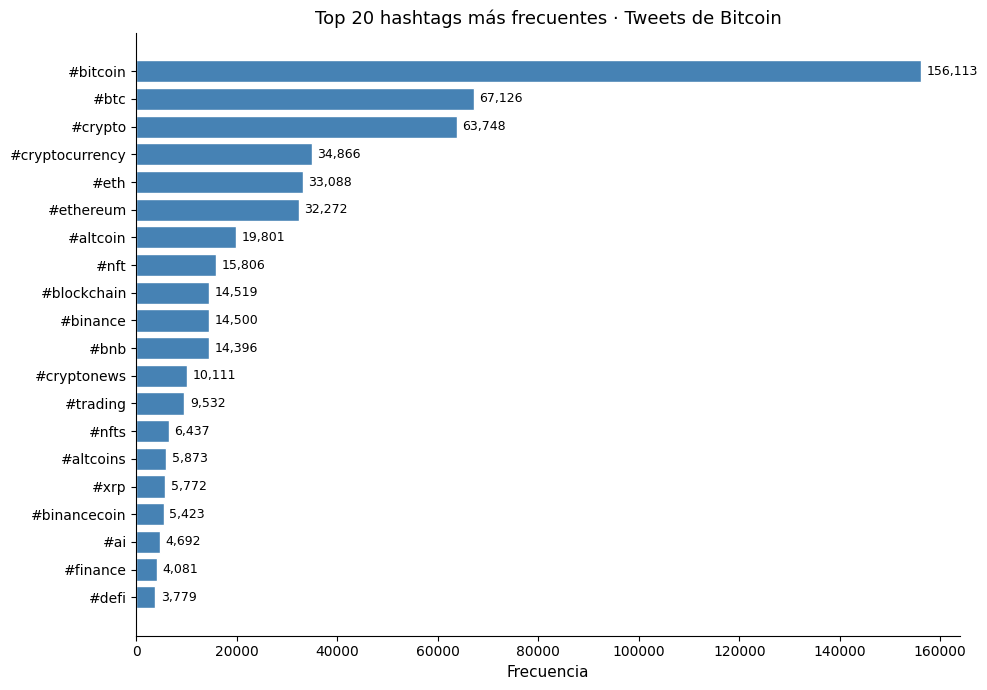

In [12]:
top20 = overall.head(20).sort('frequency')

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top20['hashtag'].to_list(), top20['frequency'].to_list(),
               color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.set_xlabel('Frecuencia', fontsize=11)
ax.set_title('Top 20 hashtags más frecuentes · Tweets de Bitcoin', fontsize=13)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### Evolución temporal de los top 5 hashtags

Aquó podemos ver si hubo picos concretos, que probablemente coincidan con alguna noticia importante sobre Bitcoin (sobre adopción, regulaciones, etc.).

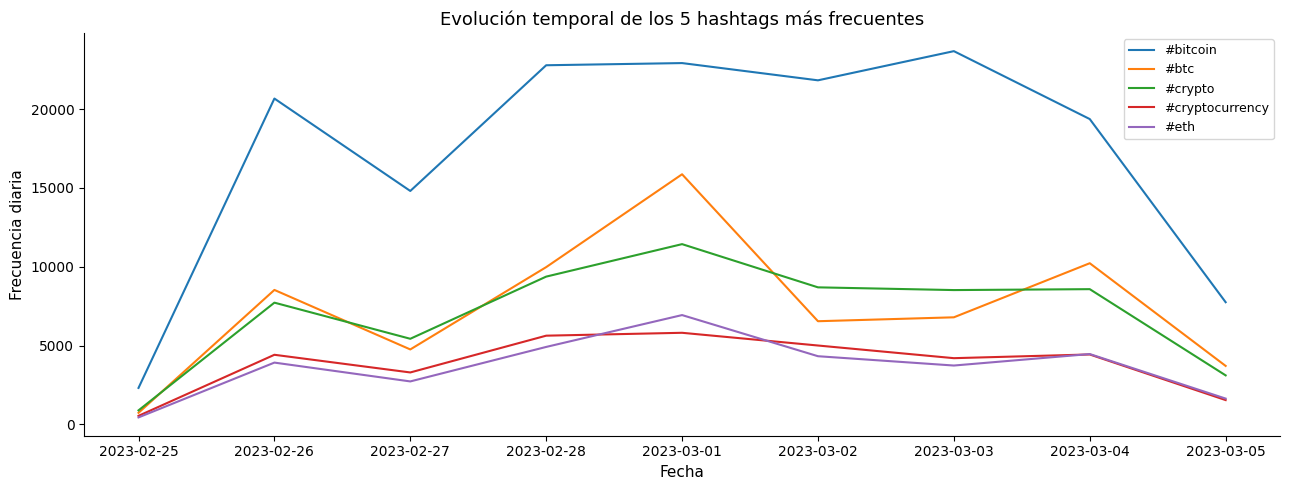

In [13]:
top5_tags = overall.head(5)['hashtag'].to_list()

by_date_top5 = by_date.filter(pl.col('hashtag').is_in(top5_tags))

pivot = (
    by_date_top5
    .pivot(index='date', on='hashtag', values='frequency', aggregate_function='sum')
    .fill_null(0)
    .sort('date')
)

dates = pivot['date'].to_list()

fig, ax = plt.subplots(figsize=(13, 5))
for tag in top5_tags:
    if tag in pivot.columns:
        ax.plot(dates, pivot[tag].to_list(), label=tag, linewidth=1.5)

ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Frecuencia diaria', fontsize=11)
ax.set_title('Evolución temporal de los 5 hashtags más frecuentes', fontsize=13)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### ¿Hay bots?

El enunciado pregunta si los hashtags podrían venir casi todos de unos pocos perfiles. Para verlo miro qué usuarios acumulan más usos de hashtags en total. Si unos pocos concentran un porcentaje muy alto, podría ser actividad automatizada, que en Twitter con criptomonedas sería bastante habitual.

In [14]:
user_totals = (
    by_user
    .group_by('user_name')
    .agg(pl.col('frequency').sum().alias('total_hashtag_uses'))
    .sort('total_hashtag_uses', descending=True)
)

total_uses = user_totals['total_hashtag_uses'].sum()
top20_users = user_totals.head(20)
top20_pct = top20_users['total_hashtag_uses'].sum() / total_uses * 100

print(f"Total usos de hashtag en el dataset: {total_uses:,}")
print(f"Top 20 usuarios concentran el {top20_pct:.1f}% de todos los usos de hashtag\n")
display(top20_users)


Total usos de hashtag en el dataset: 899,474
Top 20 usuarios concentran el 29.5% de todos los usos de hashtag



user_name,total_hashtag_uses
str,u32
"""Ethereum Yoda""",61020
"""BNB Price Tracker""",32491
"""Trader Jet Telegram Bot""",22754
"""Trackify | #1 BTC Price Action…",20832
"""Documenting Crypto""",17246
…,…
"""Crypto bits""",4651
"""Adept Asia Consulting""",4091
"""Slippage Tolerance""",4070


/var/folders/m7/d1hvl0714gq2zktsp7gjrfmc0000gn/T/ipykernel_56411/1773898811.py:13: UserWarning: Glyph 128421 (\N{DESKTOP COMPUTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/m7/d1hvl0714gq2zktsp7gjrfmc0000gn/T/ipykernel_56411/1773898811.py:13: UserWarning: Glyph 128752 (\N{SATELLITE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/m7/d1hvl0714gq2zktsp7gjrfmc0000gn/T/ipykernel_56411/1773898811.py:13: UserWarning: Glyph 128225 (\N{SATELLITE ANTENNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/m7/d1hvl0714gq2zktsp7gjrfmc0000gn/T/ipykernel_56411/1773898811.py:13: UserWarning: Glyph 128314 (\N{UP-POINTING RED TRIANGLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/rodri/Library/Mobile Documents/com~apple~CloudDocs/UTAD/Asignaturas/Búsqueda y Análisis de la Información/UTAD-BAIN-PRACTICAS/ACTIVIDAD_2/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128421 (\N{DESKT

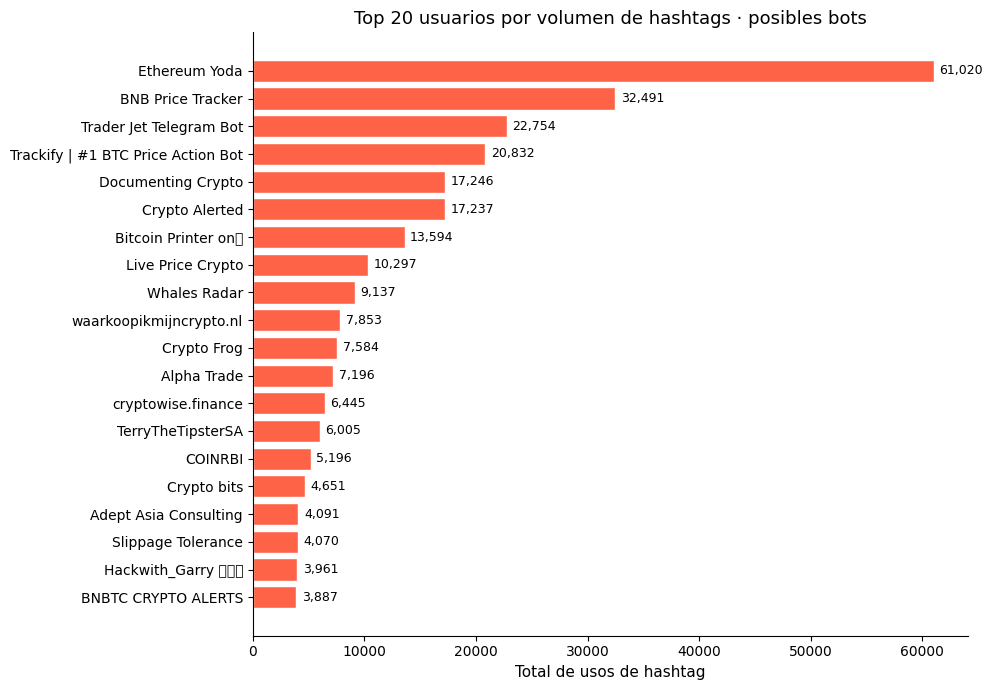

In [15]:
top20_plot = top20_users.sort('total_hashtag_uses')

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    top20_plot['user_name'].to_list(),
    top20_plot['total_hashtag_uses'].to_list(),
    color='tomato', edgecolor='white',
)
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.set_xlabel('Total de usos de hashtag', fontsize=11)
ax.set_title('Top 20 usuarios por volumen de hashtags · posibles bots', fontsize=13)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## 5. Wordcloud

Por último la wordcloud. El tamaño de cada palabra es proporcional a su frecuencia, así que de un vistazo se ve qué temas son más frecuentes.

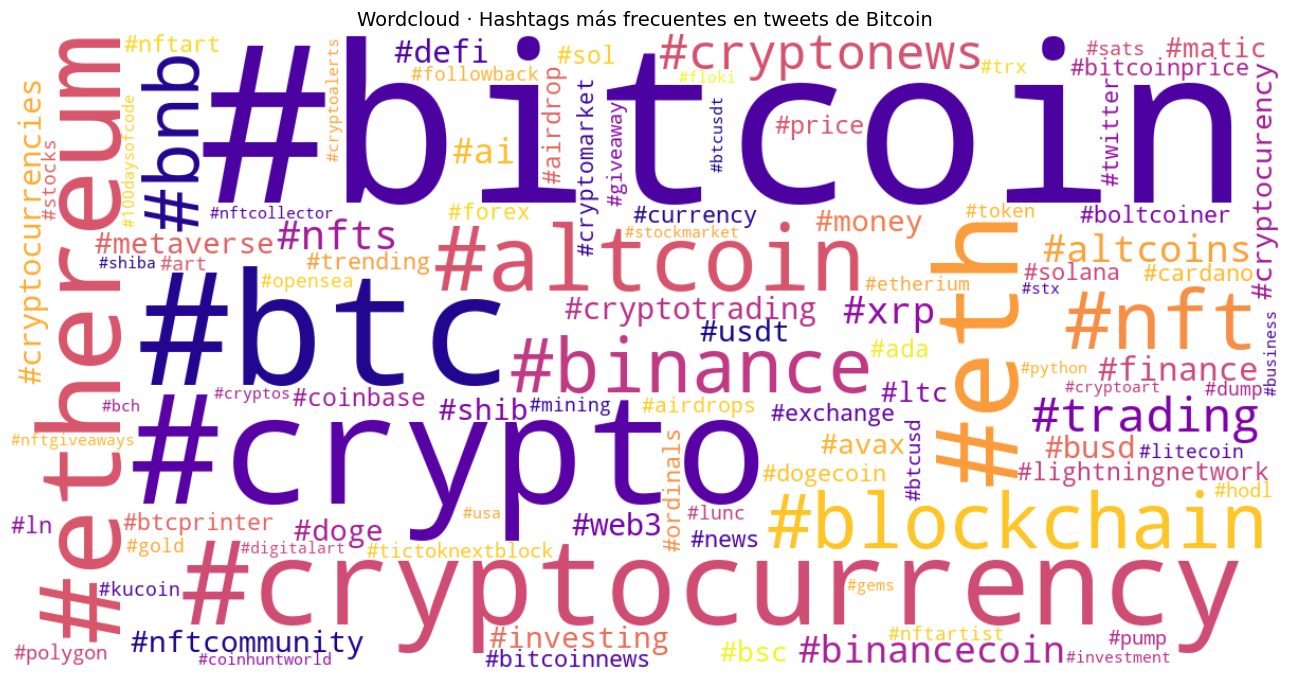

In [16]:
extractor.generate_hashtag_wordcloud(overall_df=overall, max_words=100, figsize=(13, 7))


## Conclusiones

Algunas cosas que me han llamado la atención:

- La evolución temporal tiene picos bastante claros que seguramente coinciden con movimientos del mercado
- Si el top de usuarios concentra un porcentaje alto del total de hashtags, hay bastantes probabilidades de que algunos sean bots o cuentas automatizadas. En el mundo crypto esto es muy habitual para inflar tendencias